<a href="https://colab.research.google.com/github/gerryfrank10/ComputerVision/blob/main/08_PyTorch_CNN_architectures.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from tqdm.notebook import trange, tqdm
from tempfile import TemporaryDirectory
import pdb

import torch as tc
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader

In [2]:
def show_img(im, ax=None, figsize=(8,8), title=None):
    if not ax: _,ax = plt.subplots(1,1,figsize=figsize)
    if len(im.shape)==2: im = np.tile(im[:,:,None], 3)
    ax.imshow(im);
    ax.xaxis.set_visible(False)
    ax.yaxis.set_visible(False)
    if title: ax.set_title(title)
    return ax

In [3]:
def show_imgs(ims, rows=1, figsize=(16,8), title=[None]):
    title = title*len(ims) if len(title) == 1 else title
    _,ax = plt.subplots(rows, len(ims)//rows, figsize=figsize)
    [show_img(im,ax_,title=tit) for im,ax_,tit in zip(ims,ax.flatten(),title)]
    return ax

# Better training loop

In [4]:
def one_epoch(net, loss, dl, opt=None, metric=None):

    if opt: net.train()  # only affects some layers
    else:   net.eval()

    L, M = [], []
    for xb, yb in tqdm(dl, leave=False):  # was "iter(dl)"" but not really needed in a loop
        xb, yb = xb.cuda(), yb.cuda()
        if opt:                           # equivalent to "if opt is not None"
            y_ = net(xb)
            l = loss(y_, yb)
            opt.zero_grad()
            l.backward()
            opt.step()
        else:
            with tc.no_grad():
                y_ = net(xb)
                l = loss(y_, yb)
        L.append(l.detach().cpu().numpy())
        if metric: M.append(metric(y_, yb).cpu().numpy())

    return L, M

In [ ]:
accuracy = lambda y_,yb: (y_.max(dim=1)[1] == yb).float().mean()

In [ ]:
def fit(net, tr_dl, val_dl, loss=nn.CrossEntropyLoss(), epochs=3, lr=3e-3, wd=1e-3, plot=True):

    opt = optim.Adam(net.parameters(), lr=lr, weight_decay=wd)

    Ltr_hist, Lval_hist = [], []
    for epoch in trange(epochs):
        Ltr,  _    = one_epoch(net, loss, tr_dl,  opt)
        Lval, Aval = one_epoch(net, loss, val_dl, None, accuracy)
        Ltr_hist.append(np.mean(Ltr))
        Lval_hist.append(np.mean(Lval))
        print(f'epoch: {epoch}\ttraining loss: {np.mean(Ltr):0.4f}\tvalidation loss: {np.mean(Lval):0.4f}\tvalidation accuracy: {np.mean(Aval):0.2f}')

    # plot the losses
    if plot:
        _,ax = plt.subplots(1,1,figsize=(16,4))
        ax.plot(1+np.arange(len(Ltr_hist)),Ltr_hist)
        ax.plot(1+np.arange(len(Lval_hist)),Lval_hist)
        ax.grid('on')
        ax.set_xlim(left=1, right=len(Ltr_hist))
        ax.legend(['training loss', 'validation loss']);

    return Ltr_hist, Lval_hist

# STL10 Dataset (copied from previous notebook)

In [ ]:
if 'd_stl10' not in locals():
    d_stl10 = TemporaryDirectory(prefix='STL10')

In [ ]:
stl10_stats = ([0.4467, 0.4398, 0.4066], [0.2603, 0.2566, 0.2713])

transf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(*stl10_stats)
])

In [ ]:
stl10_tr_ds  = datasets.STL10(root=d_stl10.name, split='train', download=True, transform=transf)
stl10_val_ds = datasets.STL10(root=d_stl10.name, split='test',  download=True, transform=transf)

100%|██████████| 2.64G/2.64G [05:06<00:00, 8.62MB/s]


In [ ]:
bs = 16
stl10_tr_dl  = DataLoader(stl10_tr_ds,  batch_size=bs,   shuffle=True,  num_workers=2)
stl10_val_dl = DataLoader(stl10_val_ds, batch_size=2*bs, shuffle=False, num_workers=2)

# Network architectures

In the previous lecture we have built a simple CNN. In the process, we made a number of design choices, for example:
- the number of convolution layers
- the number of channels of each conv layer
- the convolutional kernel size and stride
- location of max-pooling operations - every 2 conv layers? every 3 conv layers? every 10 conv layers?
- ...and more!

In [ ]:
# input: [bs,3,h,w]
net = nn.Sequential(
    nn.Conv2d(in_channels=3,  out_channels=16, kernel_size=3, stride=1, padding=1), nn.LeakyReLU(), # [bs,16,h,w]
    nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, stride=1, padding=1), nn.LeakyReLU(), # [bs,16,h,w]
    nn.MaxPool2d(kernel_size=2, stride=2),                                                          # [bs,16,h/2,w/2]
    nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1), nn.LeakyReLU(), # [bs,32,h/2,w/2]
    nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, stride=1, padding=1), nn.LeakyReLU(), # [bs,32,h/2,w/2]
    nn.AdaptiveAvgPool2d((4,4)),                                                                    # [bs,32,4,4]
    nn.Flatten(),                                                                                   # [bs,32*4*4]
    nn.Linear(32*4*4,10)                                                                            # [bs,10]
).cuda()

net

Sequential(
  (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): LeakyReLU(negative_slope=0.01)
  (2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): LeakyReLU(negative_slope=0.01)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): LeakyReLU(negative_slope=0.01)
  (7): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): LeakyReLU(negative_slope=0.01)
  (9): AdaptiveAvgPool2d(output_size=(4, 4))
  (10): Flatten(start_dim=1, end_dim=-1)
  (11): Linear(in_features=512, out_features=10, bias=True)
)

## PyTorch model zoo (`torchvision.models`)

Over the years a number of CNN architectures have been developed. Some of them became very popular among the computer vision community.

What it means for us is that rather than making up a network architecture like we did list time round, we can **use an existing architecture** (with slight modifications), which from the many published studies, is known to work well!

Many of these come bundled with PyTorch in the [torchvision.models](https://pytorch.org/docs/stable/torchvision/models.html) package, so we don't even need to explicitly code all the needed layers.

There is also the PyTorch Image Model library (TIMM), which has latest pre-trained models added on a regular basis: https://github.com/huggingface/pytorch-image-models.

There's almost too much choice! Fortunately, there are resources that might help you:
- Which image models are best: https://www.kaggle.com/code/jhoward/which-image-models-are-best
- The best vision models for fine-tuning: https://www.kaggle.com/code/jhoward/the-best-vision-models-for-fine-tuning/notebook

In [ ]:
import torchvision.models as models

In [ ]:
[d for d in dir(models) if not d.startswith('_')]

['AlexNet',
 'AlexNet_Weights',
 'ConvNeXt',
 'ConvNeXt_Base_Weights',
 'ConvNeXt_Large_Weights',
 'ConvNeXt_Small_Weights',
 'ConvNeXt_Tiny_Weights',
 'DenseNet',
 'DenseNet121_Weights',
 'DenseNet161_Weights',
 'DenseNet169_Weights',
 'DenseNet201_Weights',
 'EfficientNet',
 'EfficientNet_B0_Weights',
 'EfficientNet_B1_Weights',
 'EfficientNet_B2_Weights',
 'EfficientNet_B3_Weights',
 'EfficientNet_B4_Weights',
 'EfficientNet_B5_Weights',
 'EfficientNet_B6_Weights',
 'EfficientNet_B7_Weights',
 'EfficientNet_V2_L_Weights',
 'EfficientNet_V2_M_Weights',
 'EfficientNet_V2_S_Weights',
 'GoogLeNet',
 'GoogLeNetOutputs',
 'GoogLeNet_Weights',
 'Inception3',
 'InceptionOutputs',
 'Inception_V3_Weights',
 'MNASNet',
 'MNASNet0_5_Weights',
 'MNASNet0_75_Weights',
 'MNASNet1_0_Weights',
 'MNASNet1_3_Weights',
 'MaxVit',
 'MaxVit_T_Weights',
 'MobileNetV2',
 'MobileNetV3',
 'MobileNet_V2_Weights',
 'MobileNet_V3_Large_Weights',
 'MobileNet_V3_Small_Weights',
 'RegNet',
 'RegNet_X_16GF_Weights'

## AlexNet

AlexNet is the name of a convolutional neural network designed by Alex Krizhevsky, which won the [ImageNet Large Scale Visual Recognition Challenge 2012](http://image-net.org/challenges/LSVRC/2012/results.html), outperforming the runner up (traditional computer vision approach) by more than **10.8** percentage points!

Key findings of the [AlexNet paper](https://papers.nips.cc/paper/4824-imagenet-classification-with-deep-convolutional-neural-networks.pdf):
- **Depth of the model is essential** for its high performance. Comes at computational cost but made feasible via utilisation of **Graphical Processing Units (GPUs)**.
- **ReLU** non-linearity instead of traditionally used **tanh**, accelerates training by a factor of **6** without sacrificing accuracy.

Today the architecture is mostly of historical significance as this is what made **the whole field of deep learning to take off!**

Read more on [Wikipedia](https://en.wikipedia.org/wiki/AlexNet).

![](https://miro.medium.com/max/3072/1*qyc21qM0oxWEuRaj-XJKcw.png)

In [ ]:
alexnet = models.alexnet()
alexnet

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [ ]:
def count_params(md):
    cnt_all = 0
    ch, par = list(md.children()), list(md.parameters())
    for c in ch: cnt_all += count_params(c)
    if not ch and par:
        cnt_my = sum([p.numel() for p in par])
        print(md, cnt_my)
        return cnt_my
    return cnt_all

count_params(alexnet)

Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2)) 23296
Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2)) 307392
Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) 663936
Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) 884992
Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) 590080
Linear(in_features=9216, out_features=4096, bias=True) 37752832
Linear(in_features=4096, out_features=4096, bias=True) 16781312
Linear(in_features=4096, out_features=1000, bias=True) 4097000


61100840

In [ ]:
??models.AlexNet

## VGG

The VGG network (in two variants: VGG16 and VGG19) featured in the 2014 ImageNet competition. Interestingly, it **did not win** the classifiation track of the competition, taking 2nd place instead. Regardless of that, it became a very popular architecture due to its simplicity - using **only 3x3 convolutions** throughout (AlexNet used 11x11 kernel with stride 4 in the first layer).

Although VGG is still being used in some applications (e.g. as a feature extractor), it does have a number of issues:
- the number of parameters exceeds AlexNet, so it is very memory hungry and slow to train
- training of the original network was difficult because they were considered too deep back then, so smaller versions had to be pre-trained first; not an issue anymore

You can find more info in the [VGG paper](https://arxiv.org/pdf/1409.1556.pdf).

![](https://neurohive.io/wp-content/uploads/2018/11/vgg16-neural-network.jpg)

In [ ]:
vgg16 = models.vgg16()
vgg16

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [ ]:
count_params(vgg16)

Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) 1792
Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) 36928
Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) 73856
Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) 147584
Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) 295168
Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) 590080
Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) 590080
Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) 1180160
Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) 2359808
Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) 2359808
Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) 2359808
Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) 2359808
Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) 2359808
Linear(in_features=25088, out

138357544

In [ ]:
??models.VGG

## ResNet

ResNet refers to a whole family of models rather than a single architecture. The contribution of ResNet was introduction of **residual connections** which allow to train much deeper models than before (e.g. VGG19 vs ResNet-152). Currently, virtually all CNN architectures for all sorts of computer vision tasks (and not only), use the residual connections!

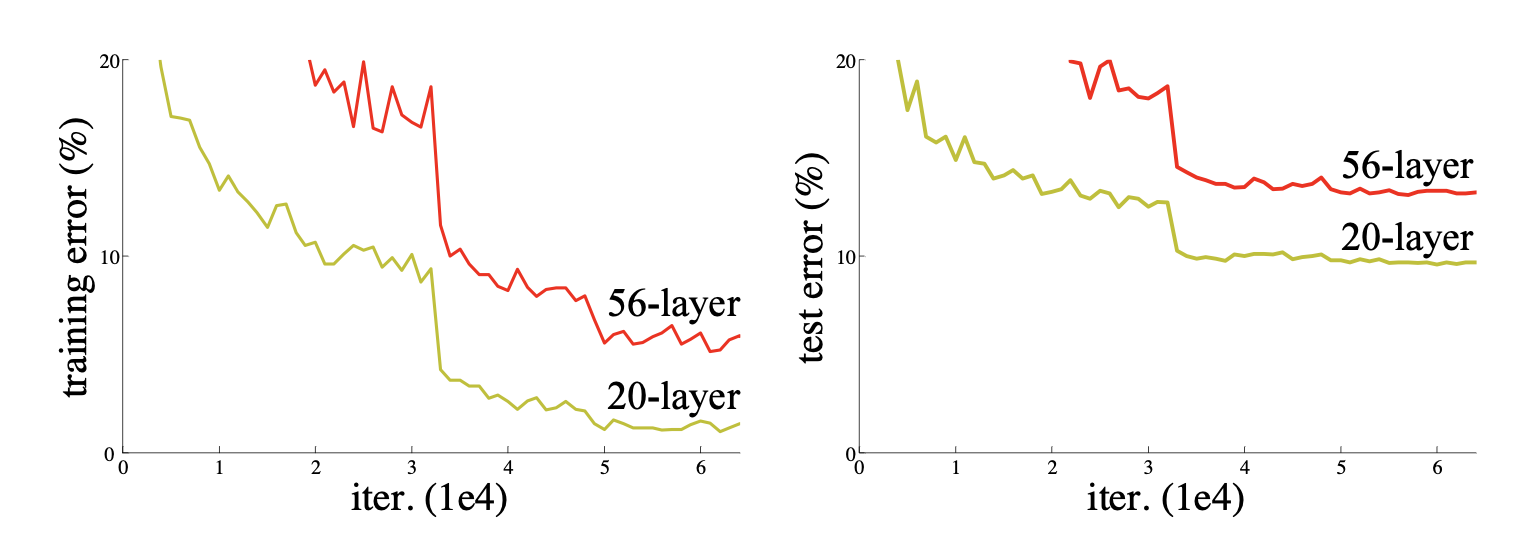

![](https://miro.medium.com/max/1000/1*kBlZtheCjJiA3F1e0IurCw.png)

More details can be found in the [ResNet paper](https://arxiv.org/pdf/1512.03385.pdf).

In [ ]:
resnet18 = models.resnet18()
resnet34 = models.resnet34()
resnet50 = models.resnet50()
resnet101 = models.resnet101()
resnet152 = models.resnet152()

In [ ]:
resnet18

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
count_params(resnet18)

Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False) 9408
BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True) 128
Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False) 36864
BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True) 128
Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False) 36864
BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True) 128
Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False) 36864
BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True) 128
Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False) 36864
BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True) 128
Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False) 73728
BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=Tr

11689512

### ResNet block from scratch

In [ ]:
# our old network with some additional layers
net = nn.Sequential(
    nn.Conv2d(in_channels=3,  out_channels=16, kernel_size=3, stride=1, padding=1), nn.LeakyReLU(),
    nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, stride=1, padding=1), nn.LeakyReLU(),
    nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, stride=1, padding=1), nn.LeakyReLU(), # new layer
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1), nn.LeakyReLU(),
    nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, stride=1, padding=1), nn.LeakyReLU(),
    nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, stride=1, padding=1), nn.LeakyReLU(), # new layer
    nn.AdaptiveAvgPool2d((4,4)),
    nn.Flatten(),
    nn.Linear(32*4*4,10)
).cuda()

In [ ]:
class ConvRelu(nn.Module):
    def __init__(self, ch, cnt=2):
        super().__init__()
        layers = cnt * [nn.Conv2d(in_channels=ch, out_channels=ch, kernel_size=3, stride=1, padding=1), nn.LeakyReLU(inplace=True)]
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)

In [ ]:
# our old network - refactored
net1 = nn.Sequential(
    nn.Conv2d(in_channels=3,  out_channels=16, kernel_size=3, stride=1, padding=1), nn.LeakyReLU(),
    ConvRelu(16),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1), nn.LeakyReLU(),
    ConvRelu(32),
    nn.AdaptiveAvgPool2d((4,4)),
    nn.Flatten(),
    nn.Linear(32*4*4,10)
).cuda()

In [ ]:
net1

Sequential(
  (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): LeakyReLU(negative_slope=0.01)
  (2): ConvRelu(
    (block): Sequential(
      (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): LeakyReLU(negative_slope=0.01, inplace=True)
      (2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): LeakyReLU(negative_slope=0.01, inplace=True)
    )
  )
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (5): LeakyReLU(negative_slope=0.01)
  (6): ConvRelu(
    (block): Sequential(
      (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): LeakyReLU(negative_slope=0.01, inplace=True)
      (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): LeakyReLU(negative_slope=0.01, inplace=True)
    )
  )
  (7): AdaptiveAvgPool2d(output_size=(4, 4))
  (8

In [ ]:
class ConvReluRes(nn.Module):
    def __init__(self, ch, cnt=2):
        super().__init__()
        layers = cnt * [nn.Conv2d(in_channels=ch, out_channels=ch, kernel_size=3, stride=1, padding=1), nn.LeakyReLU(inplace=True)]
        self.resblock = nn.Sequential(*layers)

    def forward(self, x):
        return self.resblock(x) + x  # "+x" in this single line of code makes it a ResNet (and has some serious implications)!
#         return tc.cat((self.resblock(x), x), dim=1)  # DenseNet does this instead

In [ ]:
ConvReluRes(32)

ConvReluRes(
  (resblock): Sequential(
    (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.01, inplace=True)
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): LeakyReLU(negative_slope=0.01, inplace=True)
  )
)

In [ ]:
resnet = nn.Sequential(
    nn.Conv2d(in_channels=3,  out_channels=16, kernel_size=3, stride=1, padding=1), nn.LeakyReLU(),
    ConvReluRes(16),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1), nn.LeakyReLU(),
    ConvReluRes(32),
    nn.AdaptiveAvgPool2d((4,4)),
    nn.Flatten(),
    nn.Linear(32*4*4,10)
).cuda()

In [ ]:
resnet

Sequential(
  (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): LeakyReLU(negative_slope=0.01)
  (2): ConvReluRes(
    (resblock): Sequential(
      (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): LeakyReLU(negative_slope=0.01, inplace=True)
      (2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): LeakyReLU(negative_slope=0.01, inplace=True)
    )
  )
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (5): LeakyReLU(negative_slope=0.01)
  (6): ConvReluRes(
    (resblock): Sequential(
      (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): LeakyReLU(negative_slope=0.01, inplace=True)
      (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): LeakyReLU(negative_slope=0.01, inplace=True)
    )
  )
  (7): AdaptiveAvgPool2d(output_size=

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/313 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

epoch: 0	training loss: 2.0569	validation loss: 1.9702	validation accuracy: 0.29


  0%|          | 0/313 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

epoch: 1	training loss: 1.8796	validation loss: 1.7829	validation accuracy: 0.36


  0%|          | 0/313 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

epoch: 2	training loss: 1.6950	validation loss: 1.6402	validation accuracy: 0.38


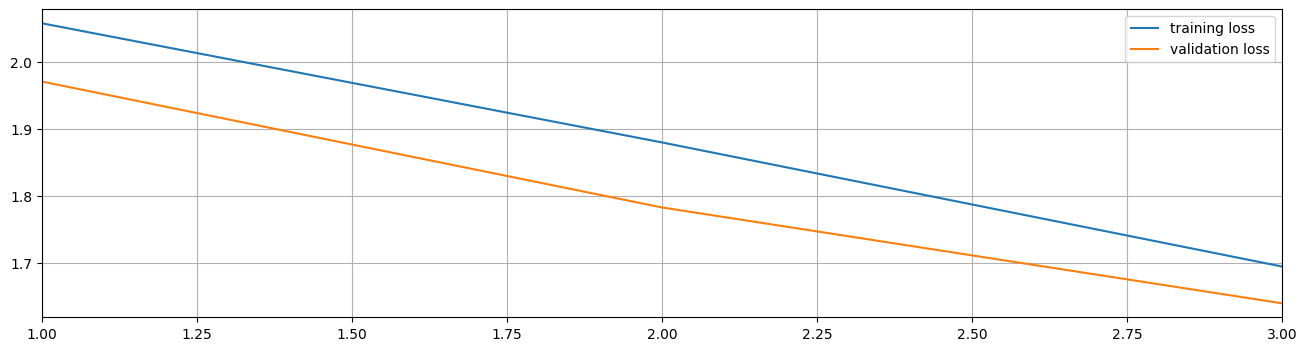

In [ ]:
fit(net1, stl10_tr_dl, stl10_val_dl);

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/313 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

epoch: 0	training loss: 1.8286	validation loss: 1.5675	validation accuracy: 0.42


  0%|          | 0/313 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

epoch: 1	training loss: 1.5129	validation loss: 1.5310	validation accuracy: 0.44


  0%|          | 0/313 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

epoch: 2	training loss: 1.3956	validation loss: 1.4580	validation accuracy: 0.46


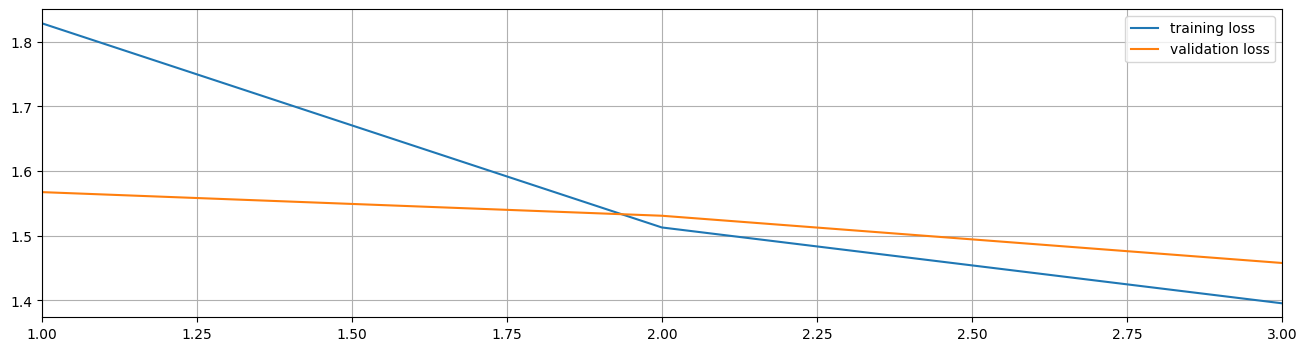

In [ ]:
fit(resnet, stl10_tr_dl, stl10_val_dl);

## SqueezeNet and MobileNet

SqueezeNet was one of the first architectures focussed on being lightweight (i.e. not having a lot of parameters) while preserving good accuracy - in this case similar to AlexNet. This has been achieved using the "fire" modules:

![](https://lh4.googleusercontent.com/EY1NLuqJtrOyg5_wp4WGQl6iGwmJJVopA0IlZKgd3MewuCL65uHwBNNR7Ao91aX6x7jSdnRQj4HV3TEeKFsFvbEGrpJfhZ74y_oVlBGobM5h_XGyYtCyv0nfojXsZiKlOvSAibuC)

More details can be found in the [SqueezeNet paper](https://arxiv.org/pdf/1602.07360.pdf).

In [ ]:
sqnet = models.squeezenet1_1()
sqnet

SqueezeNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
    (3): Fire(
      (squeeze): Conv2d(64, 16, kernel_size=(1, 1), stride=(1, 1))
      (squeeze_activation): ReLU(inplace=True)
      (expand1x1): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1))
      (expand1x1_activation): ReLU(inplace=True)
      (expand3x3): Conv2d(16, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (expand3x3_activation): ReLU(inplace=True)
    )
    (4): Fire(
      (squeeze): Conv2d(128, 16, kernel_size=(1, 1), stride=(1, 1))
      (squeeze_activation): ReLU(inplace=True)
      (expand1x1): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1))
      (expand1x1_activation): ReLU(inplace=True)
      (expand3x3): Conv2d(16, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (expand3x3_activation): ReLU(inplace=True)
    )
    (5): MaxPool2d

In [ ]:
count_params(sqnet)

Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2)) 1792
Conv2d(64, 16, kernel_size=(1, 1), stride=(1, 1)) 1040
Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1)) 1088
Conv2d(16, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) 9280
Conv2d(128, 16, kernel_size=(1, 1), stride=(1, 1)) 2064
Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1)) 1088
Conv2d(16, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) 9280
Conv2d(128, 32, kernel_size=(1, 1), stride=(1, 1)) 4128
Conv2d(32, 128, kernel_size=(1, 1), stride=(1, 1)) 4224
Conv2d(32, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) 36992
Conv2d(256, 32, kernel_size=(1, 1), stride=(1, 1)) 8224
Conv2d(32, 128, kernel_size=(1, 1), stride=(1, 1)) 4224
Conv2d(32, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) 36992
Conv2d(256, 48, kernel_size=(1, 1), stride=(1, 1)) 12336
Conv2d(48, 192, kernel_size=(1, 1), stride=(1, 1)) 9408
Conv2d(48, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) 83136
Conv2d(384, 48, kernel_size

1235496

In [ ]:
mbnet = models.mobilenet_v2()
mbnet

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [ ]:
count_params(mbnet)

Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False) 864
BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True) 64
Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False) 288
BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True) 64
Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False) 512
BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True) 32
Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False) 1536
BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True) 192
Conv2d(96, 96, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=96, bias=False) 864
BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True) 192
Conv2d(96, 24, kernel_size=(1, 1), stride=(1, 1), bias=False) 2304
BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True) 48
Conv2d(24, 144, kernel_size=(1, 1

3504872

# Training and comparison

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/313 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

epoch: 0	training loss: 2.4586	validation loss: 2.3674	validation accuracy: 0.17


  0%|          | 0/313 [00:00<?, ?it/s]

...

epoch: 3	training loss: 1.8647	validation loss: 1.8364	validation accuracy: 0.23


  0%|          | 0/313 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

epoch: 4	training loss: 1.7891	validation loss: 1.7654	validation accuracy: 0.29
CPU times: user 54.3 s, sys: 5.01 s, total: 59.3 s
Wall time: 1min 22s


([np.float32(2.458552),
  np.float32(1.9976752),
  np.float32(1.8920542),
  np.float32(1.8646529),
  np.float32(1.7890505)],
 [np.float32(2.367405),
  np.float32(1.9011372),
  np.float32(1.8928732),
  np.float32(1.836354),
  np.float32(1.7654281)])

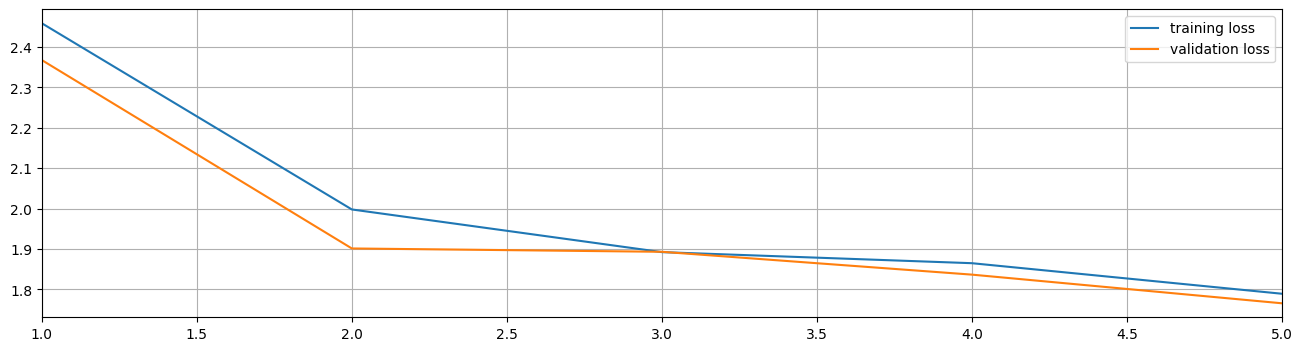

In [ ]:
%%time
alexnet = models.alexnet()
fit(alexnet.cuda(), stl10_tr_dl, stl10_val_dl, epochs=5, lr=0.001);

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/313 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

epoch: 0	training loss: 3.7088	validation loss: 2.3740	validation accuracy: 0.10


  0%|          | 0/313 [00:00<?, ?it/s]

...

epoch: 3	training loss: 2.3937	validation loss: 2.3660	validation accuracy: 0.10


  0%|          | 0/313 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

epoch: 4	training loss: 2.3886	validation loss: 2.3343	validation accuracy: 0.10
CPU times: user 3min 9s, sys: 5.81 s, total: 3min 15s
Wall time: 3min 37s


([np.float32(3.7088275),
  np.float32(2.4045787),
  np.float32(2.3953962),
  np.float32(2.3936994),
  np.float32(2.3885682)],
 [np.float32(2.3740153),
  np.float32(2.3485532),
  np.float32(2.3418589),
  np.float32(2.3660133),
  np.float32(2.3342617)])

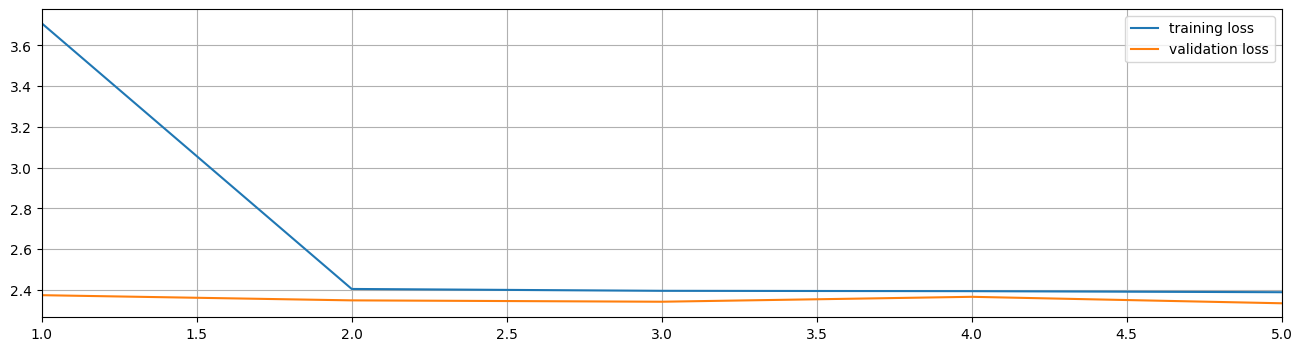

In [ ]:
%%time
vgg16 = models.vgg16()
fit(vgg16.cuda(), stl10_tr_dl, stl10_val_dl, epochs=5, lr=0.001);

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/313 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

epoch: 0	training loss: 2.0548	validation loss: 1.9641	validation accuracy: 0.26


  0%|          | 0/313 [00:00<?, ?it/s]

...

epoch: 3	training loss: 1.6809	validation loss: 1.6257	validation accuracy: 0.35


  0%|          | 0/313 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

epoch: 4	training loss: 1.6258	validation loss: 1.5974	validation accuracy: 0.38
CPU times: user 1min 14s, sys: 5.14 s, total: 1min 19s
Wall time: 1min 40s


([np.float32(2.0547683),
  np.float32(1.8316659),
  np.float32(1.7390449),
  np.float32(1.6808994),
  np.float32(1.6258012)],
 [np.float32(1.9640671),
  np.float32(1.7922863),
  np.float32(1.7406485),
  np.float32(1.6256803),
  np.float32(1.597381)])

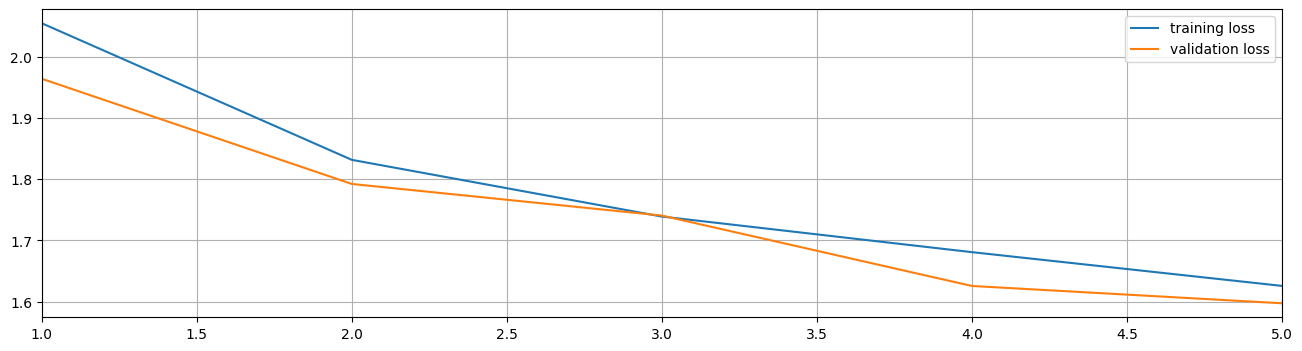

In [ ]:
%%time
resnet34 = models.resnet34()
fit(resnet34.cuda(), stl10_tr_dl, stl10_val_dl, epochs=5, lr=0.002);

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/313 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

epoch: 0	training loss: 3.2577	validation loss: 2.9808	validation accuracy: 0.10


  0%|          | 0/313 [00:00<?, ?it/s]

...

epoch: 3	training loss: 1.9056	validation loss: 1.8194	validation accuracy: 0.21


  0%|          | 0/313 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

epoch: 4	training loss: 1.8389	validation loss: 1.7902	validation accuracy: 0.28
CPU times: user 32.8 s, sys: 4.61 s, total: 37.4 s
Wall time: 1min


([np.float32(3.2577047),
  np.float32(2.5747733),
  np.float32(1.9856067),
  np.float32(1.9055609),
  np.float32(1.8388703)],
 [np.float32(2.9807916),
  np.float32(2.1305656),
  np.float32(1.8830413),
  np.float32(1.8193942),
  np.float32(1.7902366)])

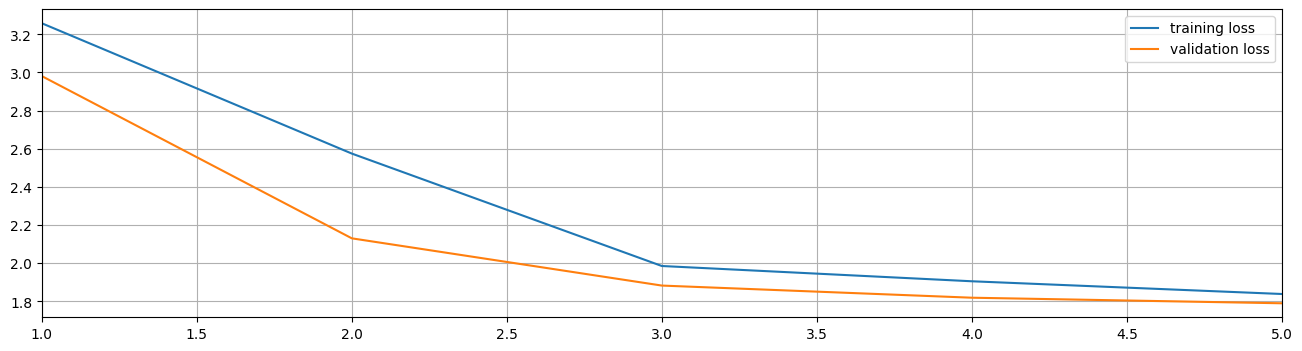

In [ ]:
%%time
sqnet = models.squeezenet1_1()
fit(sqnet.cuda(), stl10_tr_dl, stl10_val_dl, epochs=5, lr=0.002);

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/313 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

epoch: 0	training loss: 2.0602	validation loss: 1.8296	validation accuracy: 0.29


  0%|          | 0/313 [00:00<?, ?it/s]

...

epoch: 3	training loss: 1.5568	validation loss: 1.6197	validation accuracy: 0.39


  0%|          | 0/313 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

epoch: 4	training loss: 1.5005	validation loss: 1.5033	validation accuracy: 0.43
CPU times: user 1min 3s, sys: 5.18 s, total: 1min 8s
Wall time: 1min 28s


([np.float32(2.0602329),
  np.float32(1.758766),
  np.float32(1.6578774),
  np.float32(1.5568466),
  np.float32(1.5004966)],
 [np.float32(1.8295512),
  np.float32(1.7783376),
  np.float32(1.641394),
  np.float32(1.6197138),
  np.float32(1.503315)])

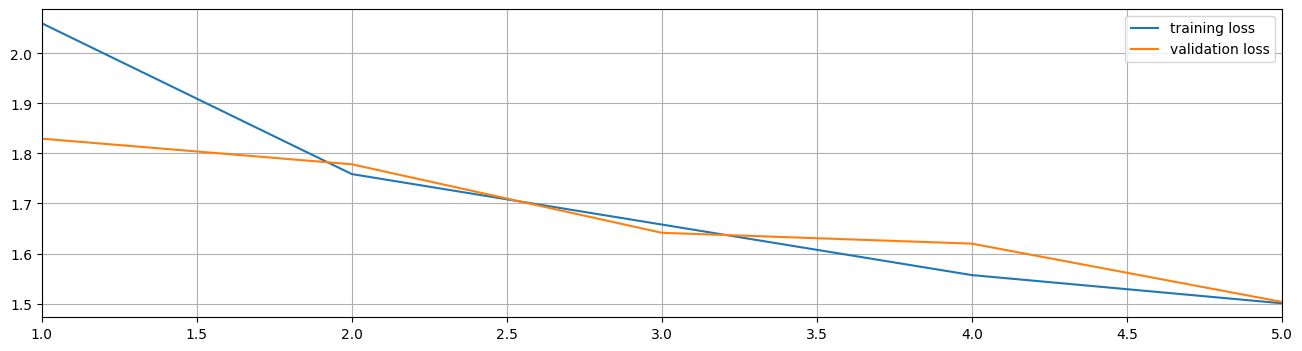

In [ ]:
%%time
mbnet = models.mobilenet_v2()
fit(mbnet.cuda(), stl10_tr_dl, stl10_val_dl, epochs=5, lr=0.001);

# Transfer learning

Transfer learning means reusing parts of existing trained models i.e. not just existing architecture but also the weights/parameters learned on a different dataset/task. This significantly speeds up training, allows you to get away with much smaller training dataset and often leads to better results than training from scratch!

## The last layer issue

In [ ]:
if not 'd_fmnist' in locals():
    d_fmnist = TemporaryDirectory(prefix='Fashion-MNIST')

Fashion MNIST is greyscale, need to convert to RGB for the pre-trained network to be able to consume:


In [ ]:
# custom transform
class To3ch():
    def __call__(self, pic):
        if pic.shape[0]==1: pic = pic.repeat(3,1,1)
        return pic

In [ ]:
fmnist_stats = (tc.Tensor(3*[0.28607249674869867]), tc.Tensor(3*[0.35299758447080976]))  # stats we have calculated previously
transf = transforms.Compose([
    transforms.ToTensor(),
    To3ch(),   # 1 -> 3 channel convesrion on the fly
    transforms.Normalize(*fmnist_stats)
])

In [ ]:
fmnist_tr_ds  = datasets.FashionMNIST(root=d_fmnist.name, train=True,  download=True, transform=transf)
fmnist_val_ds = datasets.FashionMNIST(root=d_fmnist.name, train=False, download=True, transform=transf)

100%|██████████| 26.4M/26.4M [00:00<00:00, 112MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 4.07MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 57.0MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.0MB/s]


In [ ]:
bs = 64
fmnist_tr_dl  = DataLoader(fmnist_tr_ds,  batch_size=bs,   shuffle=True,  num_workers=0)
fmnist_val_dl = DataLoader(fmnist_val_ds, batch_size=2*bs, shuffle=False, num_workers=0)

In [ ]:
fmnist_tr_ds.classes, len(fmnist_tr_ds.classes)

(['T-shirt/top',
  'Trouser',
  'Pullover',
  'Dress',
  'Coat',
  'Sandal',
  'Shirt',
  'Sneaker',
  'Bag',
  'Ankle boot'],
 10)

In [ ]:
resnet18 = models.resnet18()
resnet18

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
resnet18.fc

Linear(in_features=512, out_features=1000, bias=True)

In [ ]:
resnet18.fc = nn.Linear(512, 10)
resnet18

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

epoch: 0	training loss: 0.5123	validation loss: 0.5293	validation accuracy: 0.81


  0%|          | 0/938 [00:00<?, ?it/s]

...

epoch: 1	training loss: 0.3975	validation loss: 0.4043	validation accuracy: 0.85


  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

epoch: 2	training loss: 0.3636	validation loss: 0.4480	validation accuracy: 0.84


([np.float32(0.5123242), np.float32(0.39752367), np.float32(0.3635699)],
 [np.float32(0.52931607), np.float32(0.4042813), np.float32(0.44795653)])

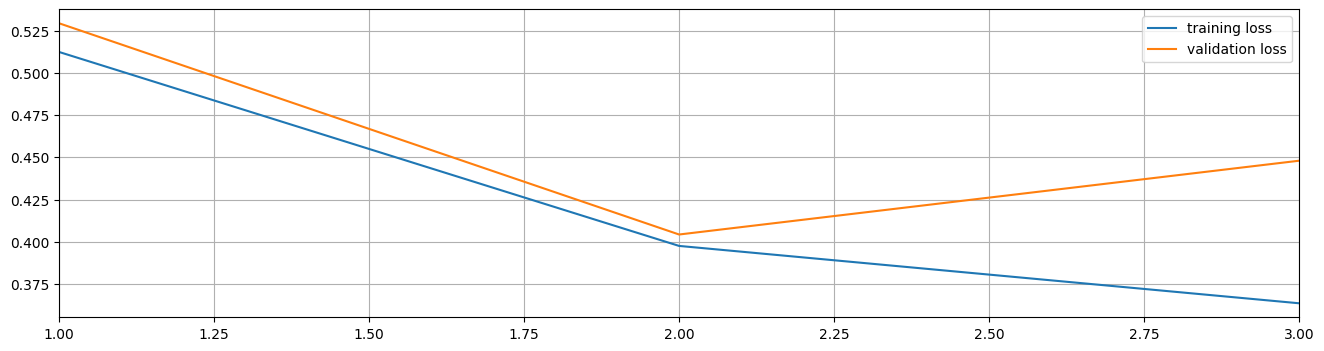

In [ ]:
fit(resnet18.cuda(), fmnist_tr_dl, fmnist_val_dl)

## Reusing parts of a trained network

### Training the last layer

In [ ]:
resnet18pt = models.resnet18(pretrained=True)
resnet18pt

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 165MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
imagenet_stats = ([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])

transf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(*imagenet_stats)
])

In [ ]:
stl10_tr_inet_ds  = datasets.STL10(root=d_stl10.name, split='train', download=True, transform=transf)
stl10_val_inet_ds = datasets.STL10(root=d_stl10.name, split='test',  download=True, transform=transf)

In [ ]:
bs = 16
stl10_tr_dl  = DataLoader(stl10_tr_inet_ds,  batch_size=bs,   shuffle=True,  num_workers=2)
stl10_val_dl = DataLoader(stl10_val_inet_ds, batch_size=2*bs, shuffle=False, num_workers=2)

In [ ]:
resnet18pt.fc = nn.Linear(512, 10)

In [ ]:
def freeze(md, fr=True):
    ch = list(md.children())
    for c in ch: freeze(c, fr)
    if not ch and not isinstance(md, tc.nn.modules.batchnorm.BatchNorm2d):  # not freezing the BatchNorm layers!
        for p in md.parameters():
#             print('---\n', md, p.requires_grad)
            p.requires_grad = not fr

In [ ]:
def freeze_to(md, ix=-1, fr=True):
    ch_all = list(md.children())
    for ch in ch_all[:ix]:
        freeze(ch, fr)

In [ ]:
freeze_to(resnet18pt, -1, True)

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/313 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

epoch: 0	training loss: 0.7924	validation loss: 0.6219	validation accuracy: 0.80


  0%|          | 0/313 [00:00<?, ?it/s]

...

epoch: 3	training loss: 0.3685	validation loss: 0.4241	validation accuracy: 0.86


  0%|          | 0/313 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

epoch: 4	training loss: 0.3409	validation loss: 0.3802	validation accuracy: 0.87
CPU times: user 35.7 s, sys: 4.9 s, total: 40.6 s
Wall time: 1min 3s


([np.float32(0.79237056),
  np.float32(0.5332852),
  np.float32(0.41631037),
  np.float32(0.3684599),
  np.float32(0.34090862)],
 [np.float32(0.6218867),
  np.float32(0.44712102),
  np.float32(0.37172267),
  np.float32(0.4240637),
  np.float32(0.38015497)])

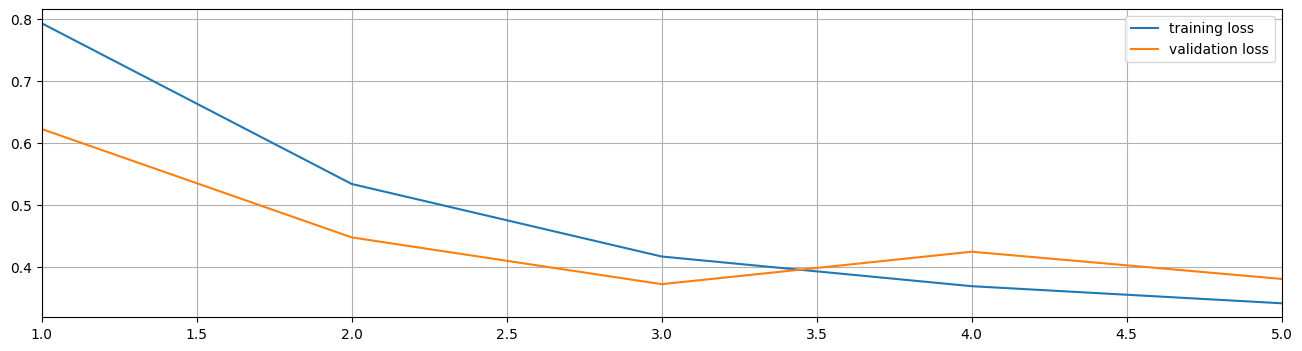

In [ ]:
%%time
fit(resnet18pt.cuda(), stl10_tr_dl, stl10_val_dl, epochs=5, lr=3e-3); # 3e-3 = 3/1000 = 0.003

### Fine-tuning

In [ ]:
freeze_to(resnet18pt, -3, False)

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/313 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

epoch: 0	training loss: 0.2806	validation loss: 0.3406	validation accuracy: 0.89


  0%|          | 0/313 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

epoch: 1	training loss: 0.1415	validation loss: 0.3320	validation accuracy: 0.89
CPU times: user 15.7 s, sys: 2 s, total: 17.7 s
Wall time: 27 s


([np.float32(0.2806217), np.float32(0.14151381)],
 [np.float32(0.34055677), np.float32(0.3320383)])

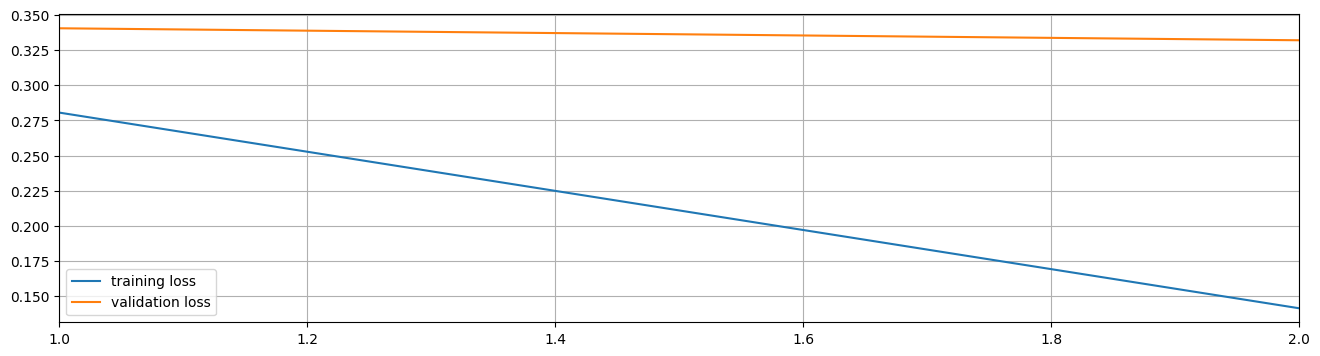

In [ ]:
%%time
fit(resnet18pt.cuda(), stl10_tr_dl, stl10_val_dl, epochs=2, lr=0.0001);

## Why does it work?






In [ ]:
w = models.alexnet(pretrained=True).features[0].weight.data
w.shape

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth
100%|██████████| 233M/233M [00:02<00:00, 95.4MB/s]


torch.Size([64, 3, 11, 11])

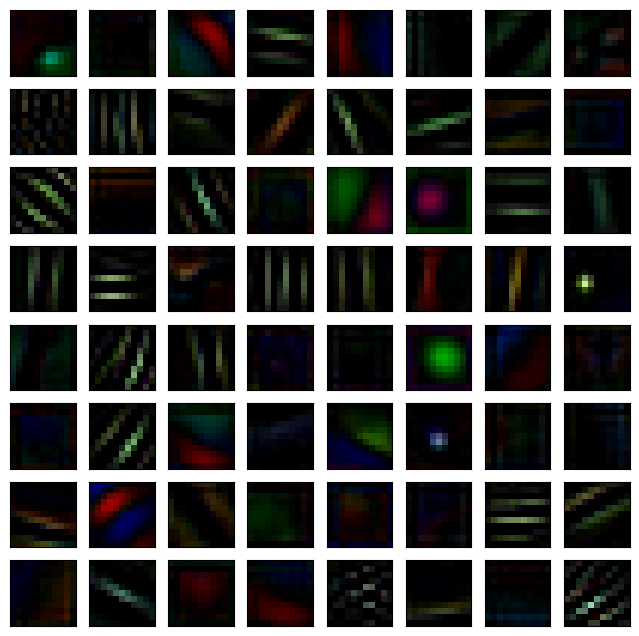

In [ ]:
rows = int(np.sqrt(w.shape[0]))
show_imgs(w.numpy().transpose(0,2,3,1).clip(0,1), rows=rows, figsize=(rows,rows));

In [ ]:
# increase the contrast
wv = w.view(*w.shape[:1], -1)
mn, mx = wv.min(dim=-1)[0][...,None,None,None], wv.max(dim=-1)[0][...,None,None,None]
wn = ((w - mn)/(mx-mn))

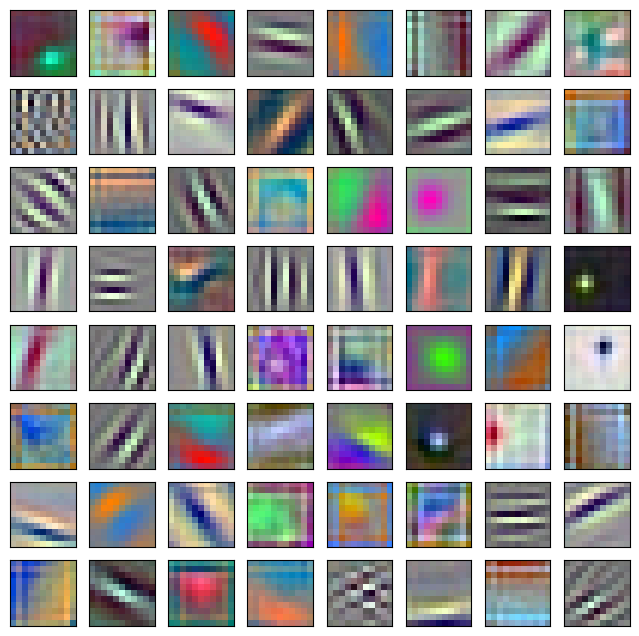

In [ ]:
show_imgs(wn.numpy().transpose(0,2,3,1), rows=rows, figsize=(rows,rows));

# Homework

## For all

Modify the training loop to support mixed-precision training.

## For volunteers

Prepare a notebook comparing transfer learning with and without freezing the `BatchNorm` layers on STL10, Fashion-MNIST and one other dataset of your choice.